Imports

In [32]:
import pandas as pd
import numpy as np
import yfinance as yf
import matplotlib.pyplot as plt
from sympy import primerange

Duomenys is yahoo finance AAPL

In [33]:
data1 = yf.download("AAPL", start='2023-01-01', end='2023-12-31')

data1.reset_index(inplace=True)
data1.columns = data1.columns.get_level_values(0)  # Flatten MultiIndex columns

print(data1.dtypes)
print(data1)

[*********************100%***********************]  1 of 1 completed

Price
Date      datetime64[ns]
Close            float64
High             float64
Low              float64
Open             float64
Volume             int64
dtype: object
Price       Date       Close        High         Low        Open     Volume
0     2023-01-03  122.982712  128.715409  122.097730  128.105761  112117500
1     2023-01-04  124.251198  126.512816  122.992561  124.772352   89113600
2     2023-01-05  122.933548  125.637653  122.677892  125.008335   80962700
3     2023-01-06  127.456787  128.115604  122.805730  123.907041   87754700
4     2023-01-09  127.977936  131.183540  127.722280  128.292603   70790800
..           ...         ...         ...         ...         ...        ...
245   2023-12-22  191.433090  193.222829  190.810137  192.995392   37149600
246   2023-12-26  190.889236  191.719831  190.671698  191.442966   28919300
247   2023-12-27  190.988129  191.334217  188.951188  190.335527   48087700
248   2023-12-28  191.413315  192.481228  191.007900  191.967044   340

Duomenys is yahoo finance NVDA

In [34]:
data2 = yf.download("NVDA", start='2023-01-01', end='2023-12-31')

data2.reset_index(inplace=True)
data2.columns = data2.columns.get_level_values(0)  # Flatten MultiIndex columns

print(data2.dtypes)
print(data2)

[*********************100%***********************]  1 of 1 completed

Price
Date      datetime64[ns]
Close            float64
High             float64
Low              float64
Open             float64
Volume             int64
dtype: object
Price       Date      Close       High        Low       Open     Volume
0     2023-01-03  14.283264  14.962755  14.064750  14.818076  401277000
1     2023-01-04  14.716300  14.820070  14.209427  14.534704  431324000
2     2023-01-05  14.233375  14.531711  14.116633  14.458873  389168000
3     2023-01-06  14.826060  14.976726  14.002889  14.441914  405044000
4     2023-01-09  15.593353  16.020404  15.107432  15.250116  504231000
..           ...        ...        ...        ...        ...        ...
245   2023-12-22  48.743362  49.295379  48.381004  49.107713  252507000
246   2023-12-26  49.191563  49.511992  48.873128  48.881114  244200000
247   2023-12-27  49.329319  49.591853  48.997907  49.423154  233648000
248   2023-12-28  49.434135  49.795493  49.324330  49.554923  246587000
249   2023-12-29  49.434135  49.908295

Psychological lane apskaiciavimas

In [35]:
def psychological_line(data, period = 12):
    data['UpDown'] = np.where(data['Close'] > data['Close'].shift(1), 1, 0)
    data['PL'] = data['UpDown'].rolling(window=period).sum() / period * 100
    return data

Psychological lane brezimas

KeyError: ('Volume', 'AAPL')

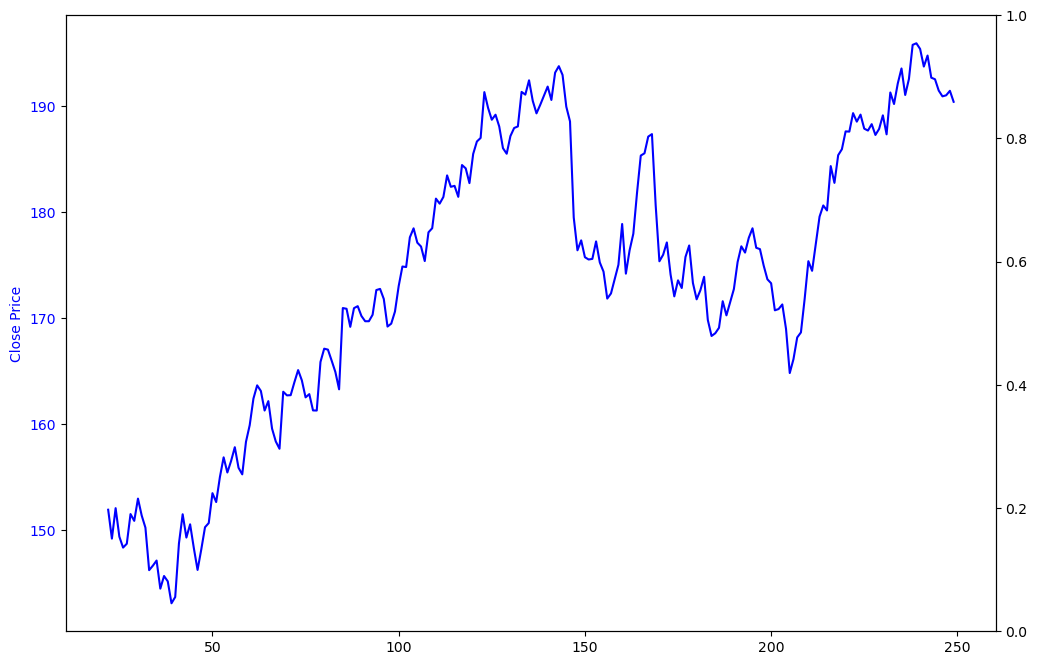

In [ ]:
data1PL = psychological_line(data1.copy())

data1PL.dropna(inplace=True)

colors = np.where(data1PL['Close'] > data1PL['Close'].shift(1), 'green', 'red')

fig, ax1 = plt.subplots(figsize=(12, 8))

ax1.plot(data1PL.index, data1PL['Close'], label='Close Price', color='blue')
ax1.set_ylabel('Close Price', color='blue')
ax1.tick_params(axis='y', labelcolor='blue')

ax2 = ax1.twinx()
ax2.bar(
    data1PL.index,
    data1PL['Volume'],
    color=colors,
    alpha=0.4,
    label='Volume'
)
ax2.set_ylim(0, data1PL['Volume'].max() * 4)
ax2.set_ylabel('Volume', color='gray')
ax2.tick_params(axis='y', labelcolor='gray')

ax3 = ax1.twinx()  # Another y-axis for PL
ax3.spines["right"].set_position(("outward", 60))
ax3.plot(data1PL.index, data1PL['PL'], label='Psychological Line (PL)', color='orange')
ax3.axhline(50, color='red', linestyle='--', label='50 Level')
ax3.set_ylabel('Psychological Line (PL)', color='orange')
ax3.tick_params(axis='y', labelcolor='orange')

ax1.legend(loc='upper left')
ax2.legend(loc='upper right')
ax3.legend(loc='lower right')

Prime number bands apskaiciavimas

Pirminiu radimas

In [ ]:
def pirminiu_radimas(kaina, pirminiai):
   
    if isinstance(kaina, pd.Series):
        kaina = kaina.iloc[0] if len(kaina) > 0 else np.nan
    kaina = float(kaina)
    
    zemesnis_pirminis = max([p for p in pirminiai if p < kaina], default=np.nan)
    aukstesnis_pirminis = min([p for p in pirminiai if p > kaina], default=np.nan)
    return zemesnis_pirminis, aukstesnis_pirminis

In [ ]:
pirminiai = list(primerange(1, 500))

data1['Lower_Prime'] = data1['Close'].apply(lambda x: pirminiu_radimas(x, pirminiai)[0])
data1['Upper_Prime'] = data1['Close'].apply(lambda x: pirminiu_radimas(x, pirminiai)[1])

data1['Difference'] = data1['Upper_Prime'] - data1['Lower_Prime']

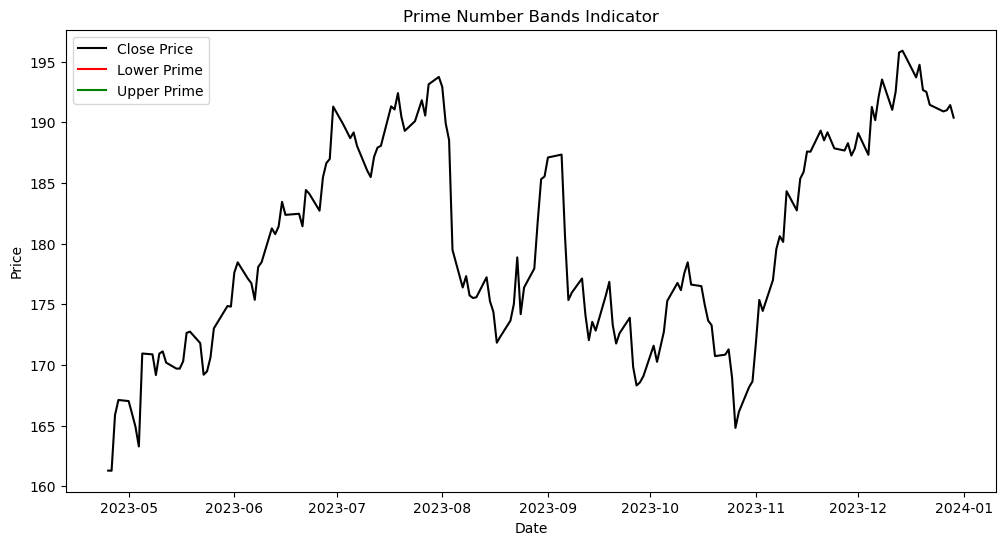

In [ ]:
plt.figure(figsize=(12, 6))
plt.plot(data1['Date'], data1['Close'], label='Close Price', color='black')
plt.plot(data1['Date'], data1['Lower_Prime'], label='Lower Prime', linestyle='-', color='red')
plt.plot(data1['Date'], data1['Upper_Prime'], label='Upper Prime', linestyle='-', color='green')

plt.fill_between(data1['Date'], data1['Lower_Prime'], data1['Upper_Prime'], color='lightblue', alpha=0.5)

plt.title('Prime Number Bands Indicator')
plt.xlabel('Date')
plt.ylabel('Price')
plt.legend()

Relative volatility apskaiciavimas

In [ ]:
data1['Returns'] = data1['Close'].pct_change()

data1['Volatility'] = data1['Returns'].rolling(window=21).std()

data1['Relative Volatility'] = data1['Volatility'] / data1['Close']

Relative volatility brezimas

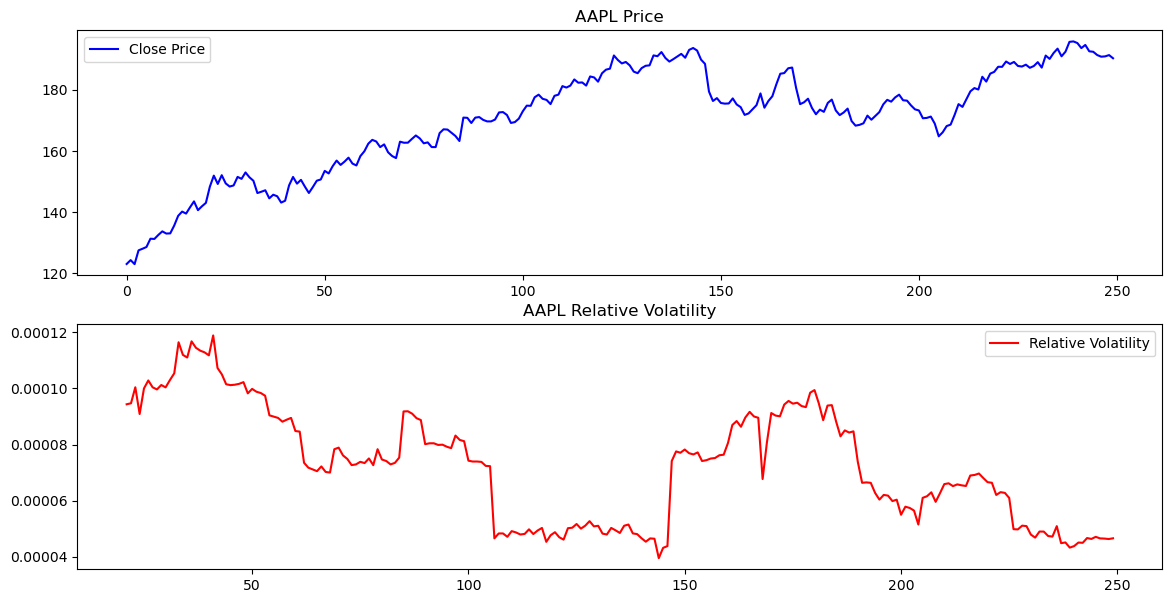

In [ ]:
plt.figure(figsize=(14, 7))

plt.subplot(2, 1, 1)
plt.plot(data1['Close'], label='Close Price', color='blue')
plt.title('AAPL Price')
plt.legend()

plt.subplot(2, 1, 2)
plt.plot(data1['Relative Volatility'], label='Relative Volatility', color='red')
plt.title('AAPL Relative Volatility')
plt.legend()